# Metabolitics - Starters Guide

Welcome to the installation and environment setup guide for Metabolitics algorithm tool proposed in https://ieeexplore.ieee.org/document/9137659 by Ali Çakmak and Hasan Çelik, and developped by other researchers.

Metabolitics employs flux variability analysis with a dynamically built objective function based on
biofluid metabolomics measurements in a personalized manner. Moreover, Metabolitics builds supervised classification models to discriminate between patients and healthy subjects based on the computed metabolic network changes.

## Cloning the repository
After getting your access to ITU Bioinformatics & Database Lab Organisation on Github clone the "metabolitics-dev" repository.

(If you don't have git on your system download and install from https://git-scm.com/downloads)

(You may want to work on your version of metabolitics, delete `.git` folder, later create your own.)
```
git clone https://github.com/itu-bioinformatics-database-lab/metabolitics-dev.git
```

## Installing required libraries
* Based on your Python distribution install required libraries except "cobra".\
__Example__: `pip install -U scikit-learn` or `conda install scikit-learn`\
(You can also download libraries using Anaconda Navigator GUI)(Or installing the requirements.txt)
* Library "cobra" should be locally imported. If it is installed on your main environment, delete it.\
(`pip uninstall cobra` or `conda uninstall --force cobra`)
* Make sure "cobra" library is in the metabolitics directory.

## Create your virtual environment for metabolitics using `metaboliticsenv.yml` file

Create the virtual environment from the `metaboliticsenv.yml` file:
```
conda env create -f metaboliticsenv.yml
```

Delete a specific environment:
```
conda env remove --name name_of_the_environment
```

## Installing IBM CPLEX as an alternative solver
* To download CPLEX Optimization Studio first create an account using your academic ITU e-mail.(https://www.ibm.com/tr-tr/products/ilog-cplex-optimization-studio)
* Once your account is confirmed go to https://www.ibm.com/academic/topic/data-science and download the software for your OS.
* You may have to install "IBM Download Director" first, from https://www-03.ibm.com/isc/esd/dswdown/dldirector/installation_en.html.
(If the file doesn't open, you may need to install Java first. Go to https://java.com to download and install the latest version of Java.)
* After the instalation has completed, you need to link CPLEX with Python.
* Go to the instalation directory of IBM CPLEX, in my case: `C:\Program Files\IBM\ILOG\CPLEX_Studio201\python`
* Open an administrator shell inside of the directory.
* Switch to your `metaboliticsenv`. First type `conda deactivate` to close the base environment. Then `conda activate metaboliticsenv`.
* If you can't switch between environments in Windows Powershell type `conda init powershell` to change setting.(You should see the name of the environment on the left, inside braces)
* Run `setup.py` with `python setup.py install` command in an administrator shell.
* In the `analysis/analysis.py` you may use `self.model.solver = "cplex"` line to change for different solvers.
```python
def __init__(self, model, without_transports=True, timeout=10 * 60):
        '''
        :param model: cobra Model
        '''
        self.model = load_network_model(model)
        self.model.solver = "cplex"
        # self.model.solver = "glpk"
        self.without_transports = without_transports
```

## Sample Run - Breast Cancer Report

In [1]:
import numpy as np
import pandas as pd

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
# pd.set_option('display.float_format', '{:.2g}'.format)

In [2]:
from sklearn_utils.utils import SkUtilsIO, filter_by_label

X_breast, y_breast = SkUtilsIO("datasets/disease_datasets/Breast_Cancer_v3_Transformed.json").from_json()
# X_breast, y_breast = filter_by_label(X, y, 'c', reverse=True)

In [3]:
from preprocessing import *
from preprocessing.metabolitics_pipeline import MetaboliticsPipeline

from utils import load_metabolite_mapping
from sklearn_utils.preprocessing import FeatureRenaming

MetaboliticsPipeline.steps['metabolite-name-mapping'] = FeatureRenaming(load_metabolite_mapping("synonym"))

# Diff score pipeline
diff_score_pipe = MetaboliticsPipeline([
        'reaction-diff', 
        'feature-selection', 
        'pathway-transformer', 
        'transport-pathway-elimination'
    ])

# Fit transform
X_breast_pathways = diff_score_pipe.fit_transform(X=X_breast, y=y_breast)

In [5]:
from sklearn_utils.utils import feature_importance_report

df = feature_importance_report(X_breast_pathways, y_breast)

In [6]:
df

labels,c,healthy,F,pval
Methionine and cysteine metabolism,581.503008,1.271498e-14,220.860457,3.441917e-33
Alanine and aspartate metabolism,1061.059157,1.024677e-13,187.639999,8.010371e-30
Tyrosine metabolism,-585.664986,-3.216141e-14,184.556456,1.212346e-29
Tryptophan metabolism,-768.548122,1.405984e+02,151.782463,8.469569e-26
Lysine metabolism,-824.393644,1.215780e+01,147.163466,2.627636e-25
Taurine and hypotaurine metabolism,1022.382000,9.058751e+00,132.872281,1.629118e-23
Extracellular exchange,322.183177,7.886060e+01,120.558574,6.647497e-22
Propanoate metabolism,667.085056,-1.421085e-13,119.878524,7.230585e-22
CoA catabolism,1114.842050,-2.094231e-14,115.417205,2.710274e-21
CoA synthesis,1060.815072,4.530168e+00,98.234473,7.578174e-19


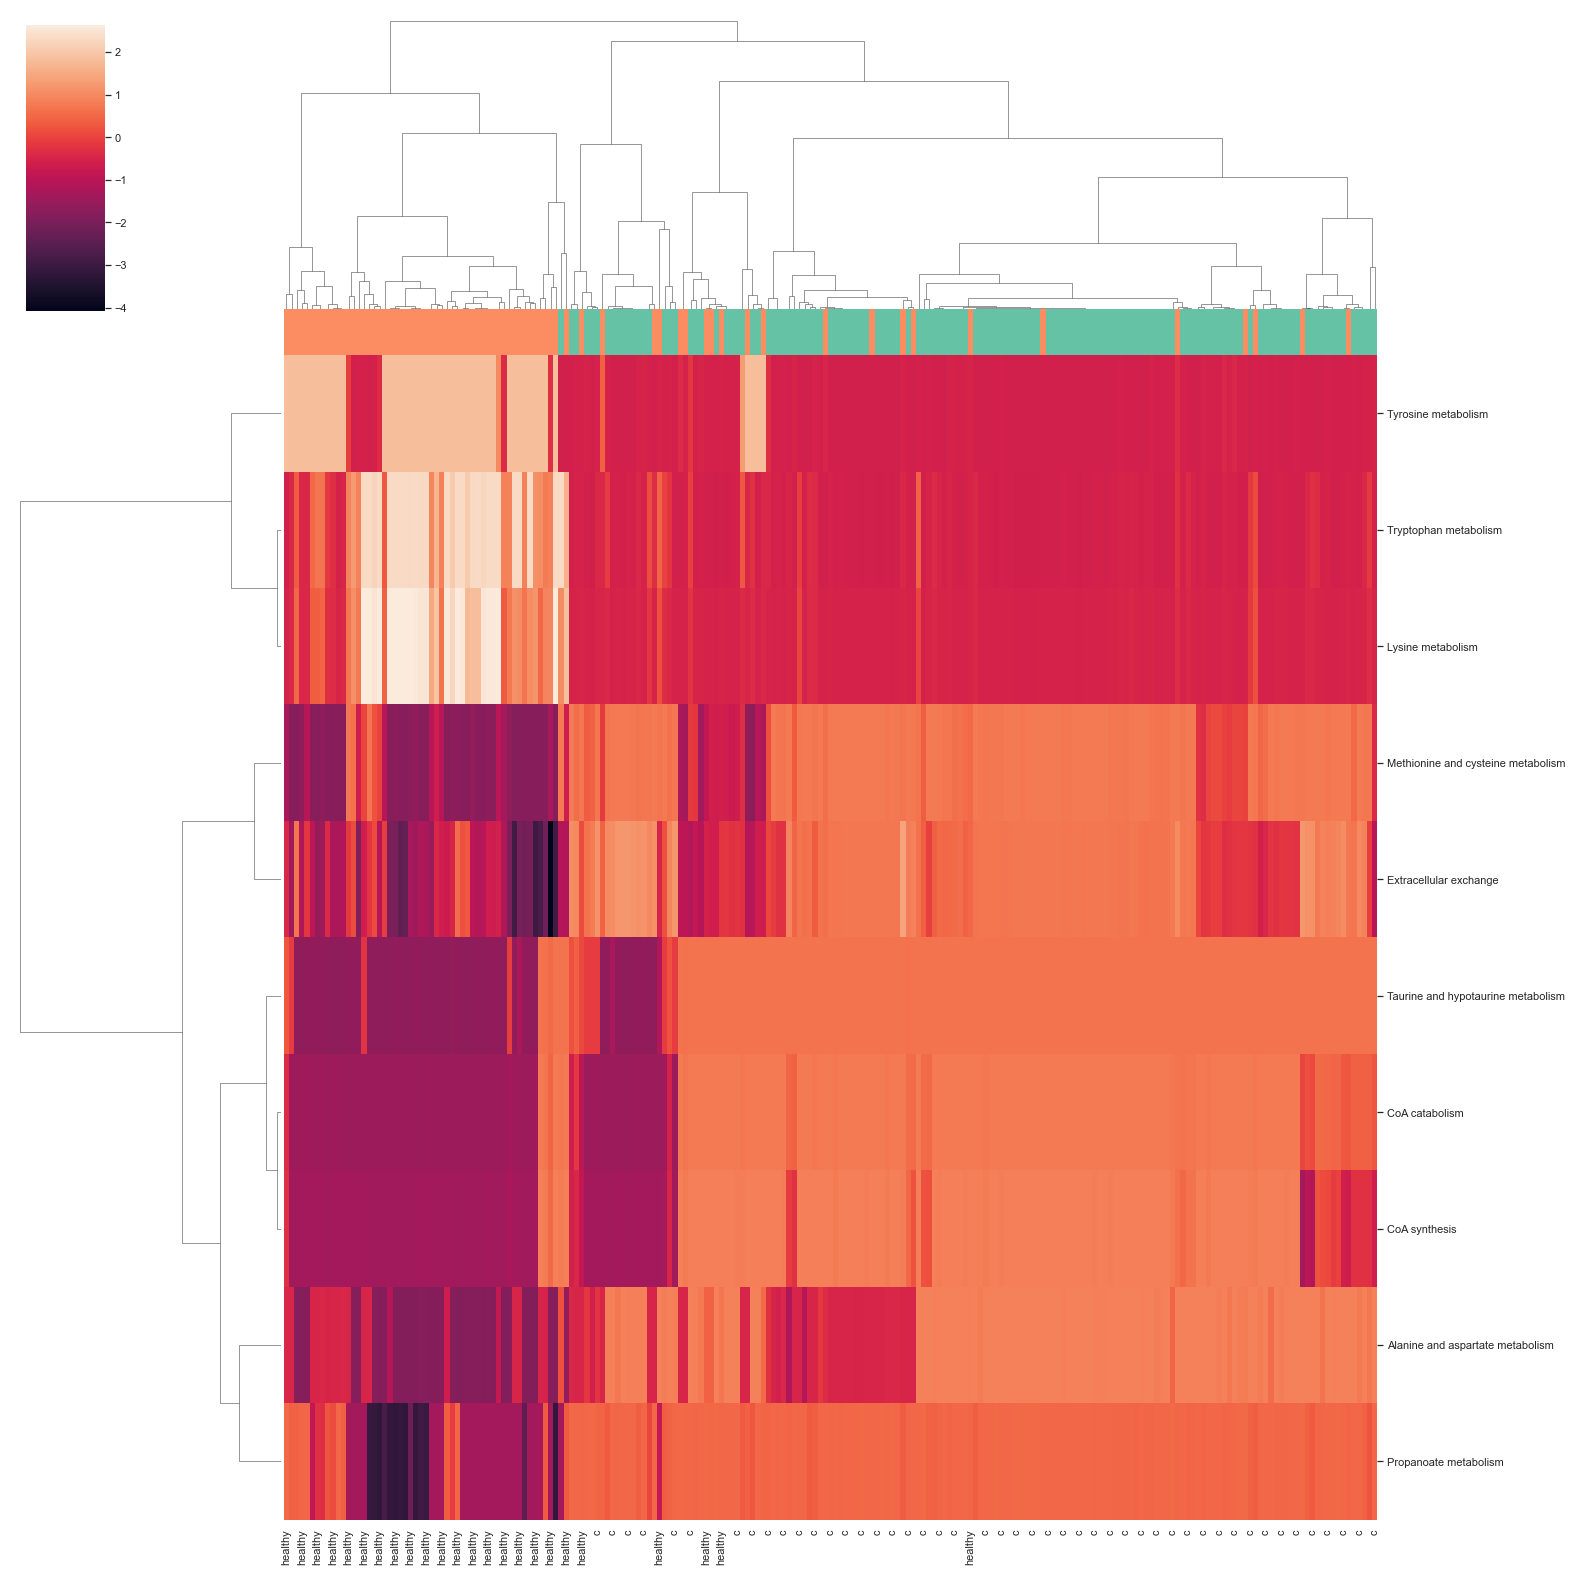

In [7]:
from sklearn_utils.visualization import plot_heatmap

plot_heatmap(X_breast_pathways, y_breast)

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

# ML pipeline
ml_pipeline = Pipeline([
            ('vect', DictVectorizer(sparse=False)),
            ('pca', PCA()),
            ('clf', LogisticRegression(C=0.3e-6, random_state=43))
        ])

In [9]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 10-fold cross validation Can play with n_splits parameter
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=43)

# Print output
scores = cross_val_score(ml_pipeline, X_breast, y_breast, cv=kf, n_jobs=None, scoring='f1_micro')
print(f'K-Fold test: {scores}')
print(f'Mean: {scores.mean().round(3)}')
print(f'Std: {scores.std().round(3)}')

K-Fold test: [0.90909091 0.95238095 0.85714286 0.95238095 0.85714286 0.9047619
 1.         0.9047619  0.95238095 0.95238095]
Mean: 0.924
Std: 0.043


Results obtained with 10-fold cross validation. Executed on UHEM.

* __K-Fold test:__ [0.90909091 0.95238095 0.85714286 0.95238095 0.85714286 0.9047619
 1.0         0.9047619  0.95238095 0.95238095]
* __Mean:__ 0.924
* __Std:__ 0.043